In [1]:
#Dataset collection with openverse

In [9]:
import requests
import pandas as pd

from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

In [14]:
OPENVERSE_URL = "https://api.openverse.org/v1/images/"

params = {
    "q": "Wall tile",
    "page_size": 20,
    "license": "cc0,by,pdm",
    "license_type": "commercial,modification",
    "mature": "false",
}

response = requests.get(
    OPENVERSE_URL,
    params=params,
    timeout=30,
)

response.raise_for_status()

data = response.json()

print("Found:", data["result_count"])
print("Takes on page:", len(data["results"]))

Found: 240
Takes on page: 20


In [15]:
results = pd.DataFrame(
    [
        {
            "title": item.get("title"),
            "creator": item.get("creator"),
            "license": item.get("license"),
            "source": item.get("source"),
            "image_url": item.get("url"),
            "page_url": item.get("foreign_landing_url"),
            "thumbnail": item.get("thumbnail"),
        }
        for item in data["results"]
    ]
)

results[:5]

,title,creator,license,source,image_url,page_url,thumbnail
0,Wall Tiles at Newark Airport,Geetesh Bajaj,by,flickr,https://live.staticflickr.com/2338/2134905190_...,https://www.flickr.com/photos/62575790@N00/213...,https://api.openverse.org/v1/images/dd79636a-5...
1,glowy edgy wall tiles,conall..,by,flickr,https://live.staticflickr.com/65535/5269892878...,https://www.flickr.com/photos/16176711@N02/526...,https://api.openverse.org/v1/images/3ca01998-9...
2,wall tiles,Mr Thinktank,by,flickr,https://live.staticflickr.com/2717/4047862501_...,https://www.flickr.com/photos/34621580@N00/404...,https://api.openverse.org/v1/images/ba2268f5-9...
3,3D wall tiles make the presentation of flowers...,MyWallArt - 3d Wallpanel,by,flickr,https://live.staticflickr.com/8017/6975992604_...,https://www.flickr.com/photos/62023099@N04/697...,https://api.openverse.org/v1/images/7317cda3-3...
4,WallArt 3D decorative wall tiles are tough eno...,MyWallArt - 3d Wallpanel,by,flickr,https://live.staticflickr.com/7079/7308322572_...,https://www.flickr.com/photos/62023099@N04/730...,https://api.openverse.org/v1/images/b9b41e32-e...


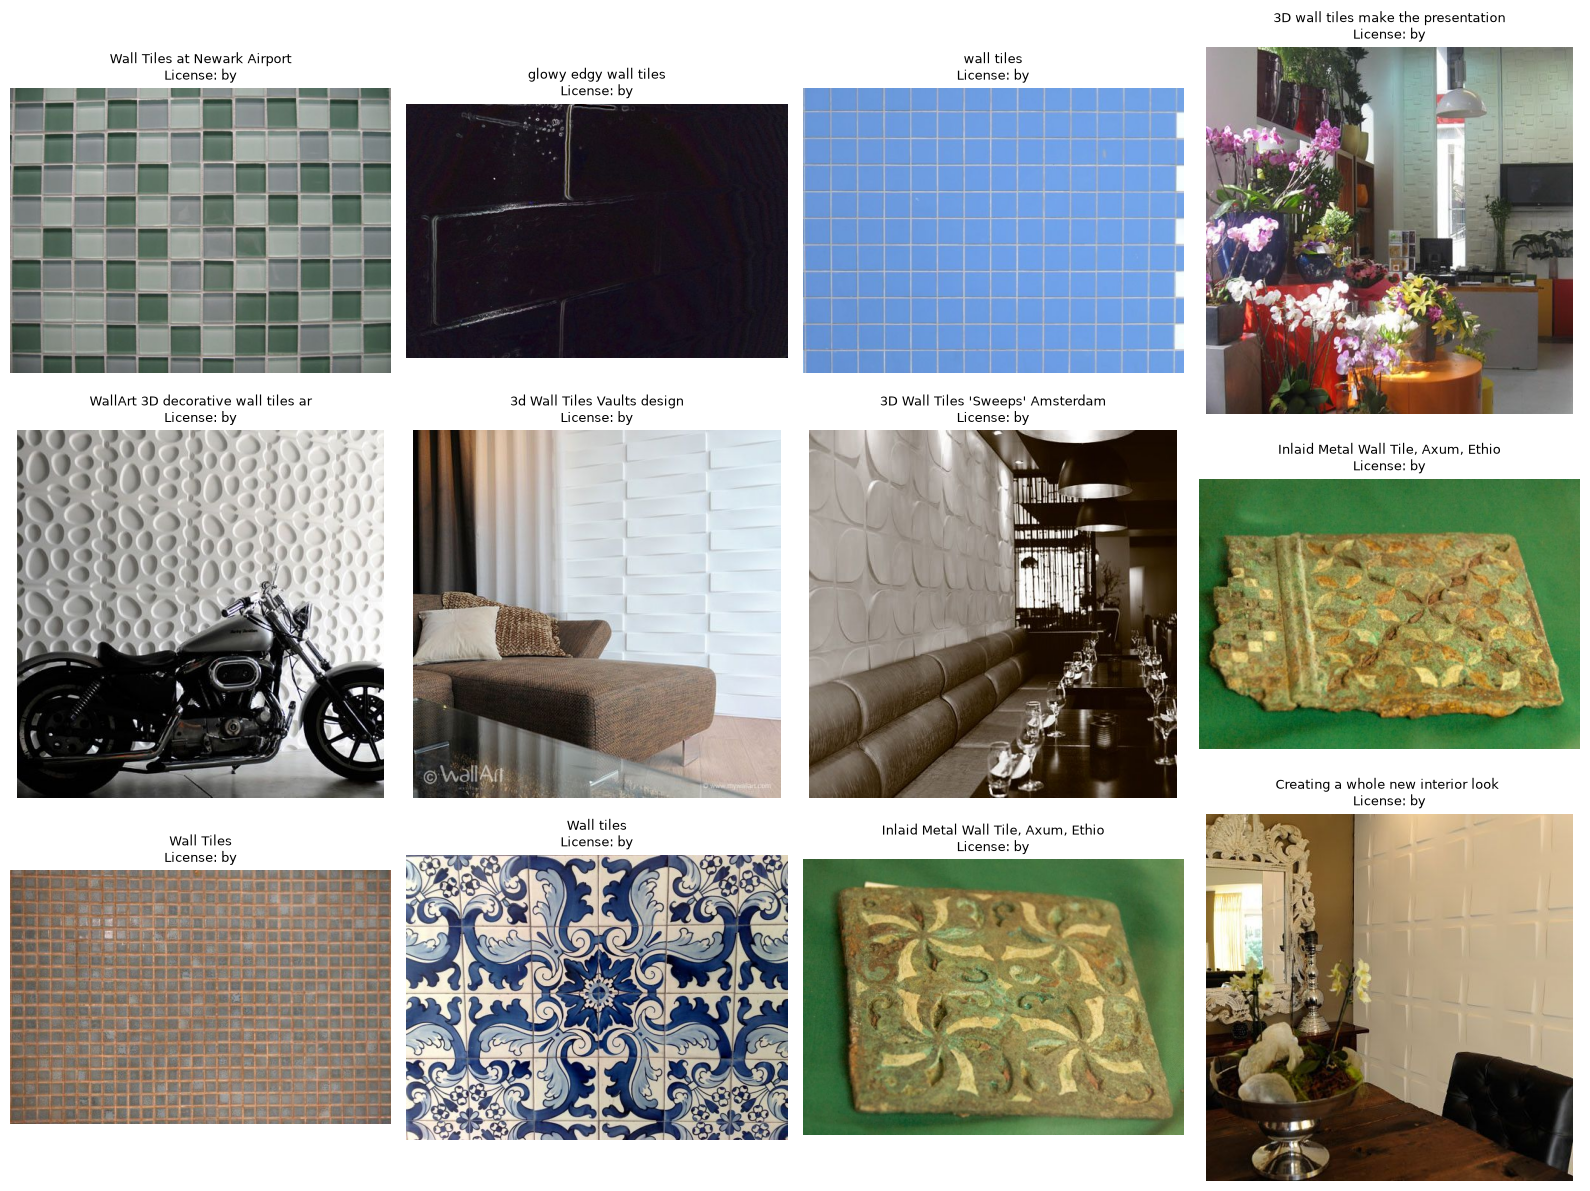

In [16]:
preview_items = data["results"][:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, item in zip(axes, preview_items):
    try:
        image_response = requests.get(
            item["thumbnail"],
            timeout=30,
        )
        image_response.raise_for_status()

        image = Image.open(
            BytesIO(image_response.content)
        ).convert("RGB")

        ax.imshow(image)
        ax.set_title(
            f'{item.get("title", "Untitled")[:35]}\n'
            f'License: {item.get("license", "unknown")}',
            fontsize=9,
        )
    except Exception as error:
        ax.text(
            0.5,
            0.5,
            f"Preview error:\n{error}",
            ha="center",
            va="center",
        )

    ax.axis("off")

plt.tight_layout()
plt.show()